# Day 2: PAD Image Processing and Feature Extraction Workshop

## 🎯 Learning Objectives
By the end of this workshop, you will:
- Understand PAD image processing challenges and solutions
- Learn different preprocessing approaches for Neural Networks vs PLS models
- Master lane segmentation and RGB extraction techniques
- Apply linear analysis methods (PLS, PCA) to PAD data
- Compare and contrast preprocessing pipelines

---

## 📋 Workshop Agenda

1. **PAD Image Processing Fundamentals** (20 mins)
2. **Neural Network Preprocessing** (20 mins)
3. **Lane Segmentation & RGB Extraction** (25 mins)
4. **Linear Analysis Techniques** (20 mins)
5. **Hands-on Integration** (15 mins)

---

## 🔧 Setup and Imports

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2 as cv
import requests
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("📦 Libraries imported successfully!")

📦 Libraries imported successfully!


In [2]:
# PAD Analytics imports
import sys
import os
sys.path.append('../src')  # Adjust path as needed

import pad_analytics as pad
from pad_analytics import regionRoutine

print(f"🚀 PAD Analytics v{pad.__version__} loaded!")
print(f"📊 Available functions: {len([x for x in dir(pad) if not x.startswith('_')])}")

2025-07-17 07:17:28.965048: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-17 07:17:29.007904: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-17 07:17:29.007936: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-17 07:17:29.007967: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-17 07:17:29.016015: I tensorflow/core/platform/cpu_feature_g

🚀 PAD Analytics v0.2.3 loaded!
📊 Available functions: 69


---
# 🖼️ Section 1: PAD Image Processing Fundamentals

## Understanding PAD Images

Paper Analytical Devices (PADs) are sophisticated chemical sensors that produce colorimetric patterns when samples are applied. Each PAD card contains:

- **12 lanes (A-L)**: Horizontal strips for different tests
- **Multiple regions per lane**: Typically 10 regions for detailed analysis
- **Colorimetric responses**: Chemical reactions produce color changes
- **Standardized layout**: Consistent positioning for automated analysis

### Key Processing Challenges:
1. **Image variability**: Different lighting, angles, cameras
2. **Region extraction**: Precise lane and region identification
3. **Color accuracy**: Consistent color measurement across conditions
4. **Model requirements**: Different preprocessing for different ML models

## 📊 Load Sample Data

In [3]:
# Load sample dataset
print("Loading sample PAD dataset...")
dataset = pad.CachedDataset('Leiberman-Lab_ChemoPADNNtraining2024_Partial-Drug-Set_v1.0')
metadata = dataset.load_dataset_metadata()

print(f"✅ Dataset loaded: {len(metadata)} cards")
print(f"📋 Columns: {list(metadata.columns)}")

# Show sample data
display(metadata.head(3))

Loading sample PAD dataset...
Loading dataset: Leiberman-Lab_ChemoPADNNtraining2024_Partial-Drug-Set_v1.0
✅ Loaded dataset from cache (3609 records)
✅ Dataset loaded: 3609 cards
📋 Columns: ['id', 'sample_id', 'sample_name', 'quantity', 'camera_type_1', 'url', 'hashlib_md5', 'image_name']


,id,sample_id,sample_name,quantity,camera_type_1,url,hashlib_md5,image_name
0,47986,80903,hydroxyurea,100,iPad,https://pad.crc.nd.edu//var/www/html/images/pa...,77ebff74a025589d0c64086b72c2a7c0,47986__80903__hydroxyurea__100.png
1,47987,81560,hydroxyurea,100,HMD Global Nokia 2.3,https://pad.crc.nd.edu//var/www/html/images/pa...,aa5b30f2bdd606ff71809a3e05f5893c,47987__81560__hydroxyurea__100.png
2,47988,81560,hydroxyurea,100,iPad,https://pad.crc.nd.edu//var/www/html/images/pa...,a2b33fab29403d5821476cf5f685e9c4,47988__81560__hydroxyurea__100.png


## 🖼️ Visualize Sample PAD Images

📸 Sample PAD Images:


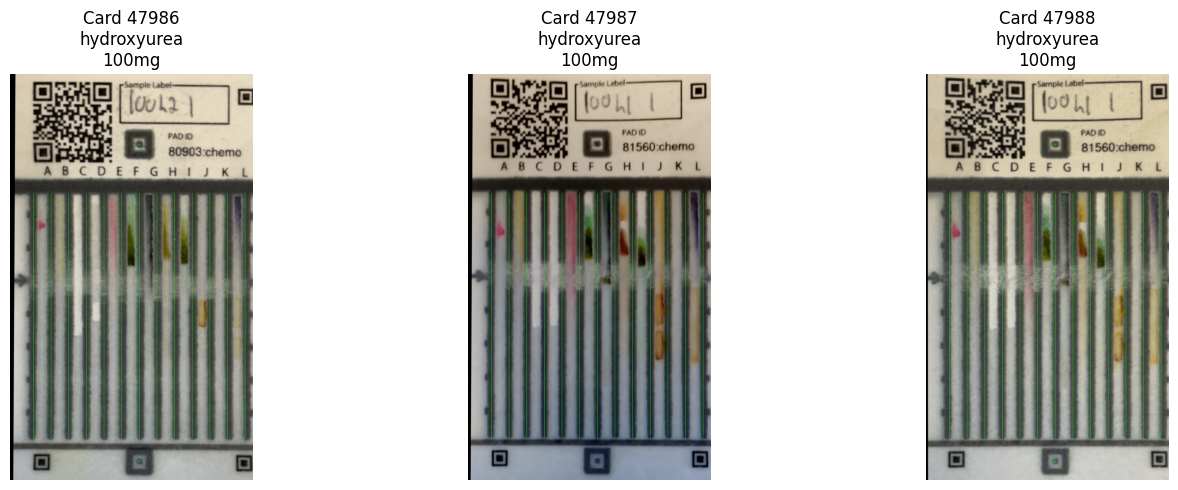

In [4]:
# Function to load and display PAD images
def load_pad_image(image_url):
    """Load PAD image from URL."""
    try:
        response = requests.get(image_url, verify=False)
        response.raise_for_status()
        return Image.open(BytesIO(response.content))
    except Exception as e:
        print(f"Failed to load image: {e}")
        return None

def display_pad_images(metadata_df, num_images=3):
    """Display multiple PAD images for comparison."""
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    
    for i in range(num_images):
        row = metadata_df.iloc[i]
        img = load_pad_image(row['url'])
        
        if img is not None:
            axes[i].imshow(img)
            axes[i].set_title(f"Card {row['id']}\n{row['sample_name']}\n{row['quantity']}mg")
            axes[i].axis('off')
        else:
            axes[i].text(0.5, 0.5, 'Failed to load', ha='center', va='center')
            axes[i].set_title(f"Card {row['id']} (Error)")
    
    plt.tight_layout()
    plt.show()

# Display sample images
print("📸 Sample PAD Images:")
display_pad_images(metadata)

---
# 🧠 Section 2: Neural Network Preprocessing

Neural networks require images as standardized pixel arrays. For PAD analysis, this involves:

## Key Steps:
1. **Cropping**: Extract active PAD area (remove borders, labels)
2. **Resizing**: Standardize to model input size (typically 454×454)
3. **Normalization**: Scale pixel values for optimal training
4. **Format conversion**: RGB → array format

## 🔍 Image Cropping and Resizing

🔍 Neural Network Preprocessing Steps:
Original image size: (730, 1220)
Cropped image size: (636, 490)
Resized image size: (454, 454)
Array shape: (454, 454, 3)
Pixel value range: 0 - 223
Normalized range: 0.000 - 0.875


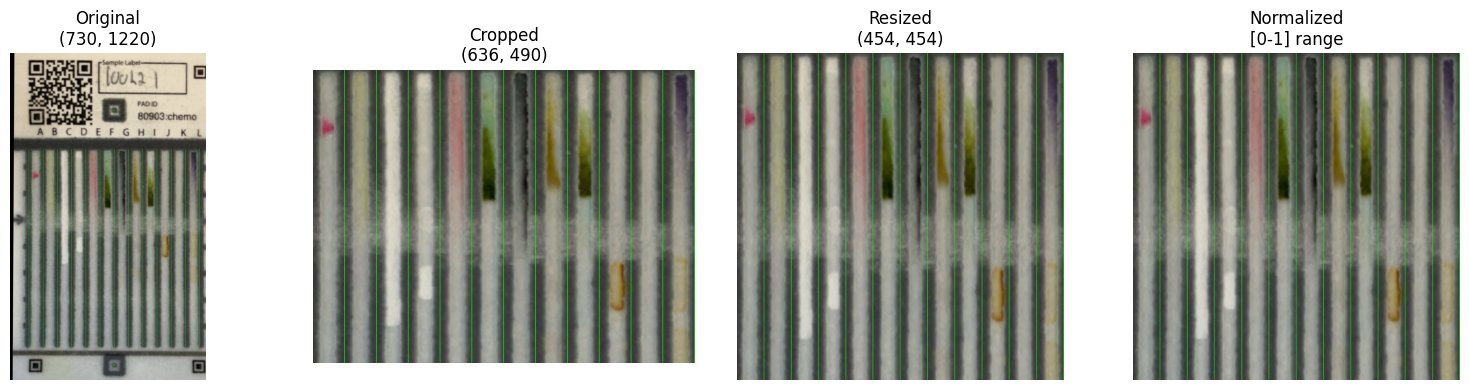

In [5]:
def demonstrate_nn_preprocessing(image_url):
    """Demonstrate step-by-step NN preprocessing."""
    
    # Load original image
    img_original = load_pad_image(image_url)
    if img_original is None:
        return
    
    print(f"Original image size: {img_original.size}")
    
    # Step 1: Crop to active area (coordinates from existing NN preprocessing)
    crop_box = (71, 359, 71 + 636, 359 + 490)  # (left, top, right, bottom)
    img_cropped = img_original.crop(crop_box)
    print(f"Cropped image size: {img_cropped.size}")
    
    # Step 2: Resize for model input
    target_size = (454, 454)
    img_resized = img_cropped.resize(target_size, Image.BICUBIC)
    print(f"Resized image size: {img_resized.size}")
    
    # Step 3: Convert to numpy array
    img_array = np.asarray(img_resized)
    print(f"Array shape: {img_array.shape}")
    print(f"Pixel value range: {img_array.min()} - {img_array.max()}")
    
    # Step 4: Normalize (example)
    img_normalized = img_array.astype(np.float32) / 255.0
    print(f"Normalized range: {img_normalized.min():.3f} - {img_normalized.max():.3f}")
    
    # Visualize the process
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(img_original)
    axes[0].set_title(f"Original\n{img_original.size}")
    axes[0].axis('off')
    
    axes[1].imshow(img_cropped)
    axes[1].set_title(f"Cropped\n{img_cropped.size}")
    axes[1].axis('off')
    
    axes[2].imshow(img_resized)
    axes[2].set_title(f"Resized\n{img_resized.size}")
    axes[2].axis('off')
    
    axes[3].imshow(img_normalized)
    axes[3].set_title(f"Normalized\n[0-1] range")
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'original': img_original,
        'cropped': img_cropped,
        'resized': img_resized,
        'array': img_array,
        'normalized': img_normalized
    }

# Demonstrate with first image
sample_url = metadata.iloc[0]['url']
print("🔍 Neural Network Preprocessing Steps:")
nn_result = demonstrate_nn_preprocessing(sample_url)

## 📊 Pixel Statistics Analysis

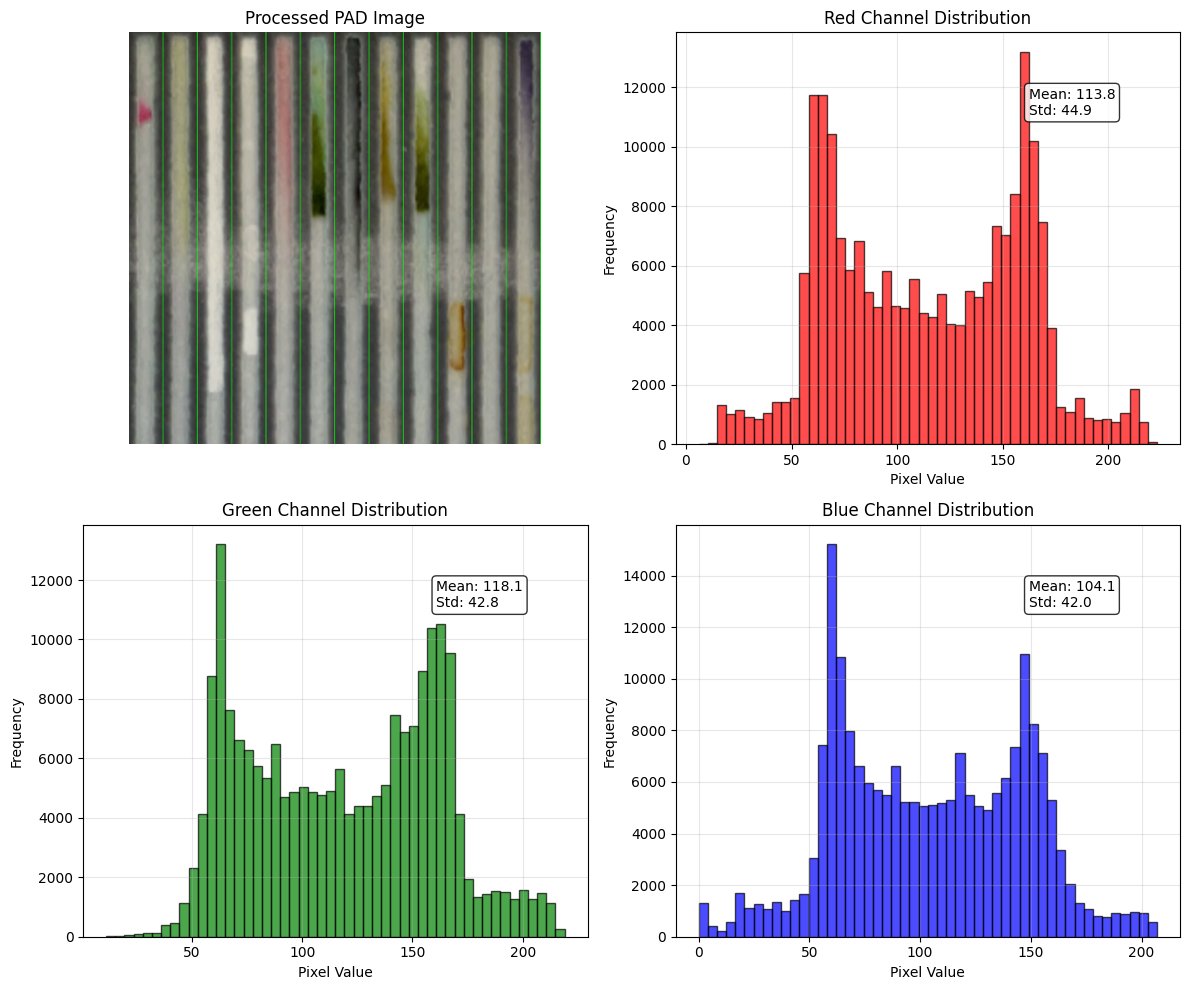

📊 Pixel Statistics Summary:


,mean,std,min,max
Red,113.81,44.94,6.0,223.0
Green,118.13,42.83,11.0,219.0
Blue,104.07,42.03,0.0,207.0


In [6]:
def analyze_pixel_statistics(img_array):
    """Analyze pixel value distributions."""
    
    # Calculate statistics for each channel
    channels = ['Red', 'Green', 'Blue']
    stats = {}
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Original image
    axes[0, 0].imshow(img_array)
    axes[0, 0].set_title('Processed PAD Image')
    axes[0, 0].axis('off')
    
    # Channel histograms
    for i, (channel, color) in enumerate(zip(channels, ['red', 'green', 'blue'])):
        channel_data = img_array[:, :, i].flatten()
        
        stats[channel] = {
            'mean': np.mean(channel_data),
            'std': np.std(channel_data),
            'min': np.min(channel_data),
            'max': np.max(channel_data)
        }
        
        if i == 0:
            ax = axes[0, 1]
        elif i == 1:
            ax = axes[1, 0]
        else:
            ax = axes[1, 1]
            
        ax.hist(channel_data, bins=50, alpha=0.7, color=color, edgecolor='black')
        ax.set_title(f'{channel} Channel Distribution')
        ax.set_xlabel('Pixel Value')
        ax.set_ylabel('Frequency')
        ax.grid(True, alpha=0.3)
        
        # Add statistics text
        stats_text = f"Mean: {stats[channel]['mean']:.1f}\nStd: {stats[channel]['std']:.1f}"
        ax.text(0.7, 0.8, stats_text, transform=ax.transAxes, 
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("📊 Pixel Statistics Summary:")
    stats_df = pd.DataFrame(stats).T
    display(stats_df.round(2))
    
    return stats

if nn_result:
    pixel_stats = analyze_pixel_statistics(nn_result['array'])

---
# 🎯 Section 3: Lane Segmentation & RGB Extraction

For PLS and other linear models, we extract specific features from defined regions rather than using raw pixels.

## PAD Lane Structure:
- **12 Lanes**: A, B, C, D, E, F, G, H, I, J, K, L
- **10 Regions per lane**: Numbered 1-10
- **3 Color channels**: R, G, B
- **Total features**: 12 × 10 × 3 = 360 features

Feature naming convention: `A1-R`, `A1-G`, `A1-B`, `A2-R`, etc.

## 🔬 Direct Region Analysis

In [7]:
def extract_rgb_features(image_url):
    """Extract RGB features using regionRoutine."""
    
    # Load image with OpenCV
    try:
        response = requests.get(image_url, verify=False)
        response.raise_for_status()
        image_array = np.asarray(bytearray(response.content), dtype=np.uint8)
        img = cv.imdecode(image_array, cv.IMREAD_COLOR)
        
        if img is None:
            print("Failed to load image with OpenCV")
            return None
            
    except Exception as e:
        print(f"Error loading image: {e}")
        return None
    
    print(f"Image loaded: {img.shape}")
    
    # Extract features using regionRoutine
    try:
        features_dict = {}
        features_dict = regionRoutine.fullRoutine(
            img, 
            regionRoutine.intFind.findMaxIntensitiesFiltered, 
            features_dict, 
            True, 
            10
        )
        
        print(f"✅ Extracted {len(features_dict)} features")
        return features_dict, img
        
    except Exception as e:
        print(f"Error in feature extraction: {e}")
        return None, img

# Extract features from sample image
print("🔬 Extracting RGB features from PAD lanes...")
sample_url = metadata.iloc[0]['url']
features, original_img = extract_rgb_features(sample_url)

🔬 Extracting RGB features from PAD lanes...
Image loaded: (1220, 730, 3)
✅ Extracted 360 features


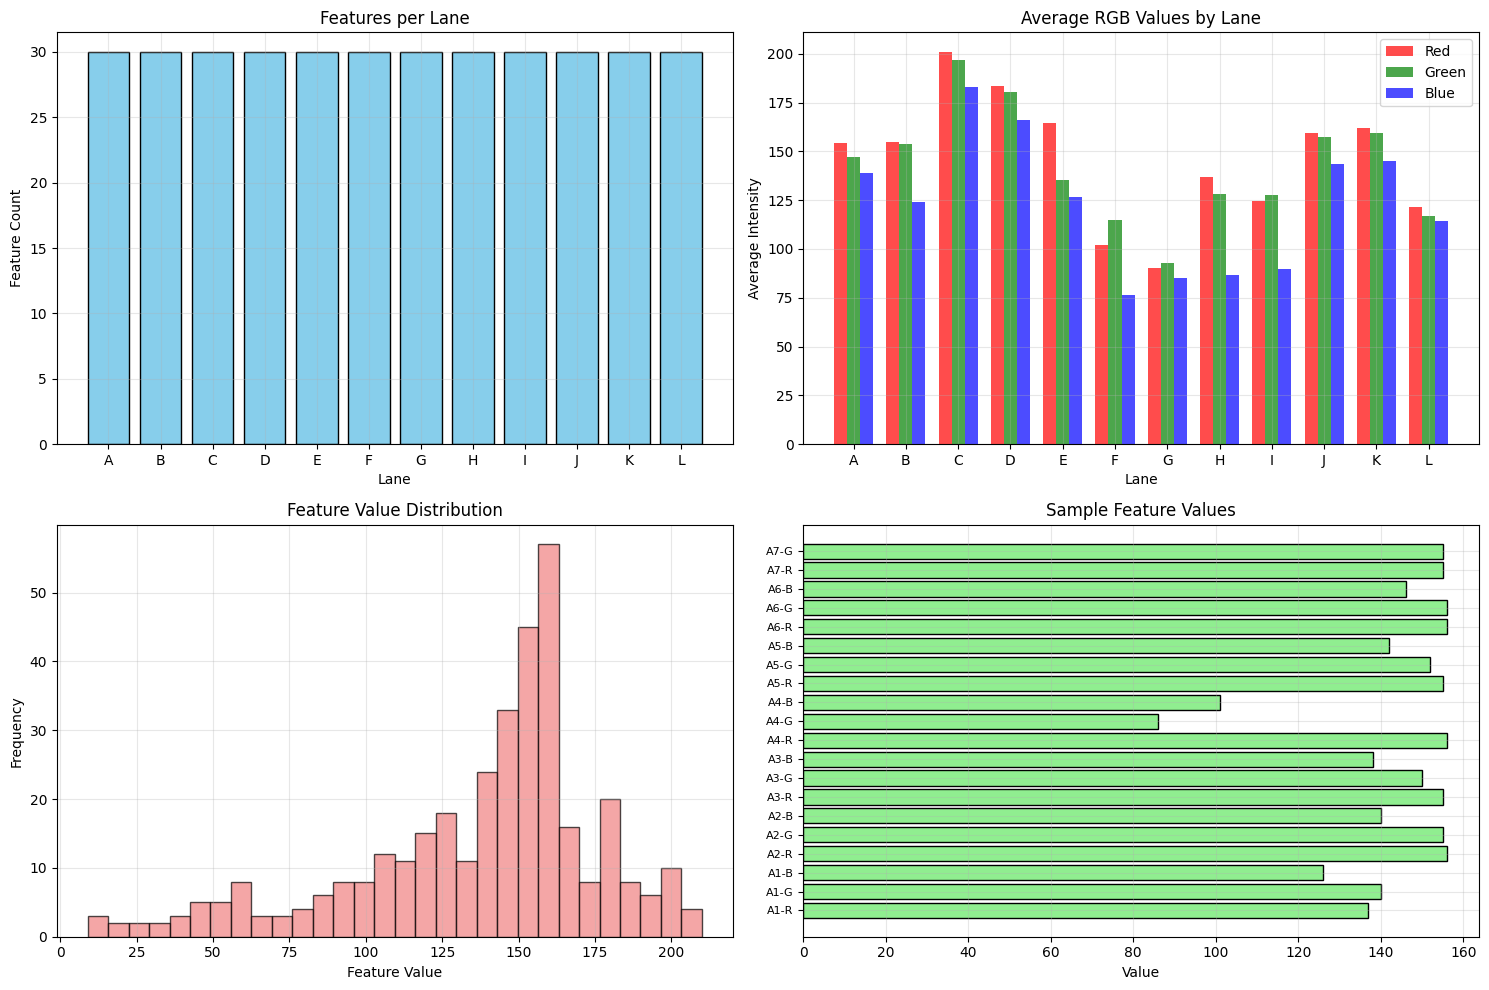

📊 RGB Feature Extraction Summary:
   • Total features extracted: 360
   • Expected features (12×10×3): 360
   • Coverage: 100.0%
   • Value range: 9.0 - 210.0
   • Average value: 137.3


In [8]:
def analyze_extracted_features(features_dict):
    """Analyze the structure and content of extracted features."""
    
    if not features_dict:
        print("No features to analyze")
        return
    
    # Convert to organized structure
    lanes = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']
    colors = ['R', 'G', 'B']
    regions = list(range(1, 11))
    
    # Organize features by lane and color
    organized_features = {}
    for lane in lanes:
        organized_features[lane] = {}
        for color in colors:
            values = []
            for region in regions:
                key = f"{lane}{region}-{color}"
                if key in features_dict:
                    values.append(features_dict[key])
                else:
                    values.append(0)  # Missing value
            organized_features[lane][color] = values
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Feature count by lane
    lane_counts = {}
    for lane in lanes:
        count = sum(1 for region in regions for color in colors 
                   if f"{lane}{region}-{color}" in features_dict)
        lane_counts[lane] = count
    
    axes[0, 0].bar(lane_counts.keys(), lane_counts.values(), color='skyblue', edgecolor='black')
    axes[0, 0].set_title('Features per Lane')
    axes[0, 0].set_xlabel('Lane')
    axes[0, 0].set_ylabel('Feature Count')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Average RGB values by lane
    lane_rgb_means = {}
    for lane in lanes:
        rgb_means = []
        for color in colors:
            values = organized_features[lane][color]
            if values:
                rgb_means.append(np.mean([v for v in values if v > 0]))
            else:
                rgb_means.append(0)
        lane_rgb_means[lane] = rgb_means
    
    x = np.arange(len(lanes))
    width = 0.25
    
    axes[0, 1].bar(x - width, [lane_rgb_means[lane][0] for lane in lanes], 
                   width, label='Red', color='red', alpha=0.7)
    axes[0, 1].bar(x, [lane_rgb_means[lane][1] for lane in lanes], 
                   width, label='Green', color='green', alpha=0.7)
    axes[0, 1].bar(x + width, [lane_rgb_means[lane][2] for lane in lanes], 
                   width, label='Blue', color='blue', alpha=0.7)
    
    axes[0, 1].set_title('Average RGB Values by Lane')
    axes[0, 1].set_xlabel('Lane')
    axes[0, 1].set_ylabel('Average Intensity')
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(lanes)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Feature distribution
    all_values = [v for v in features_dict.values() if v > 0]
    axes[1, 0].hist(all_values, bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
    axes[1, 0].set_title('Feature Value Distribution')
    axes[1, 0].set_xlabel('Feature Value')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Sample feature names
    sample_features = list(features_dict.keys())[:20]
    sample_values = [features_dict[k] for k in sample_features]
    
    axes[1, 1].barh(range(len(sample_features)), sample_values, color='lightgreen', edgecolor='black')
    axes[1, 1].set_title('Sample Feature Values')
    axes[1, 1].set_xlabel('Value')
    axes[1, 1].set_yticks(range(len(sample_features)))
    axes[1, 1].set_yticklabels(sample_features, fontsize=8)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("📊 RGB Feature Extraction Summary:")
    print(f"   • Total features extracted: {len(features_dict)}")
    print(f"   • Expected features (12×10×3): 360")
    print(f"   • Coverage: {len(features_dict)/360*100:.1f}%")
    print(f"   • Value range: {min(all_values):.1f} - {max(all_values):.1f}")
    print(f"   • Average value: {np.mean(all_values):.1f}")
    
    return organized_features

if features:
    organized = analyze_extracted_features(features)

---
# 📐 Section 4: Linear Analysis Techniques

Once we have extracted RGB features, we can apply various linear analysis methods:

## Techniques Covered:
1. **PLS (Partial Least Squares)**: Direct concentration prediction
2. **PCA (Principal Component Analysis)**: Dimensionality reduction
3. **Feature correlation analysis**: Understanding relationships
4. **Preprocessing comparison**: NN vs PLS approaches

## 🧮 PCA Analysis

🧮 Performing PCA Analysis on RGB Features...
🔄 Extracting features from 20 images...
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
   Processed 1/20 images...
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
   Processed 11/20 images...
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 fea

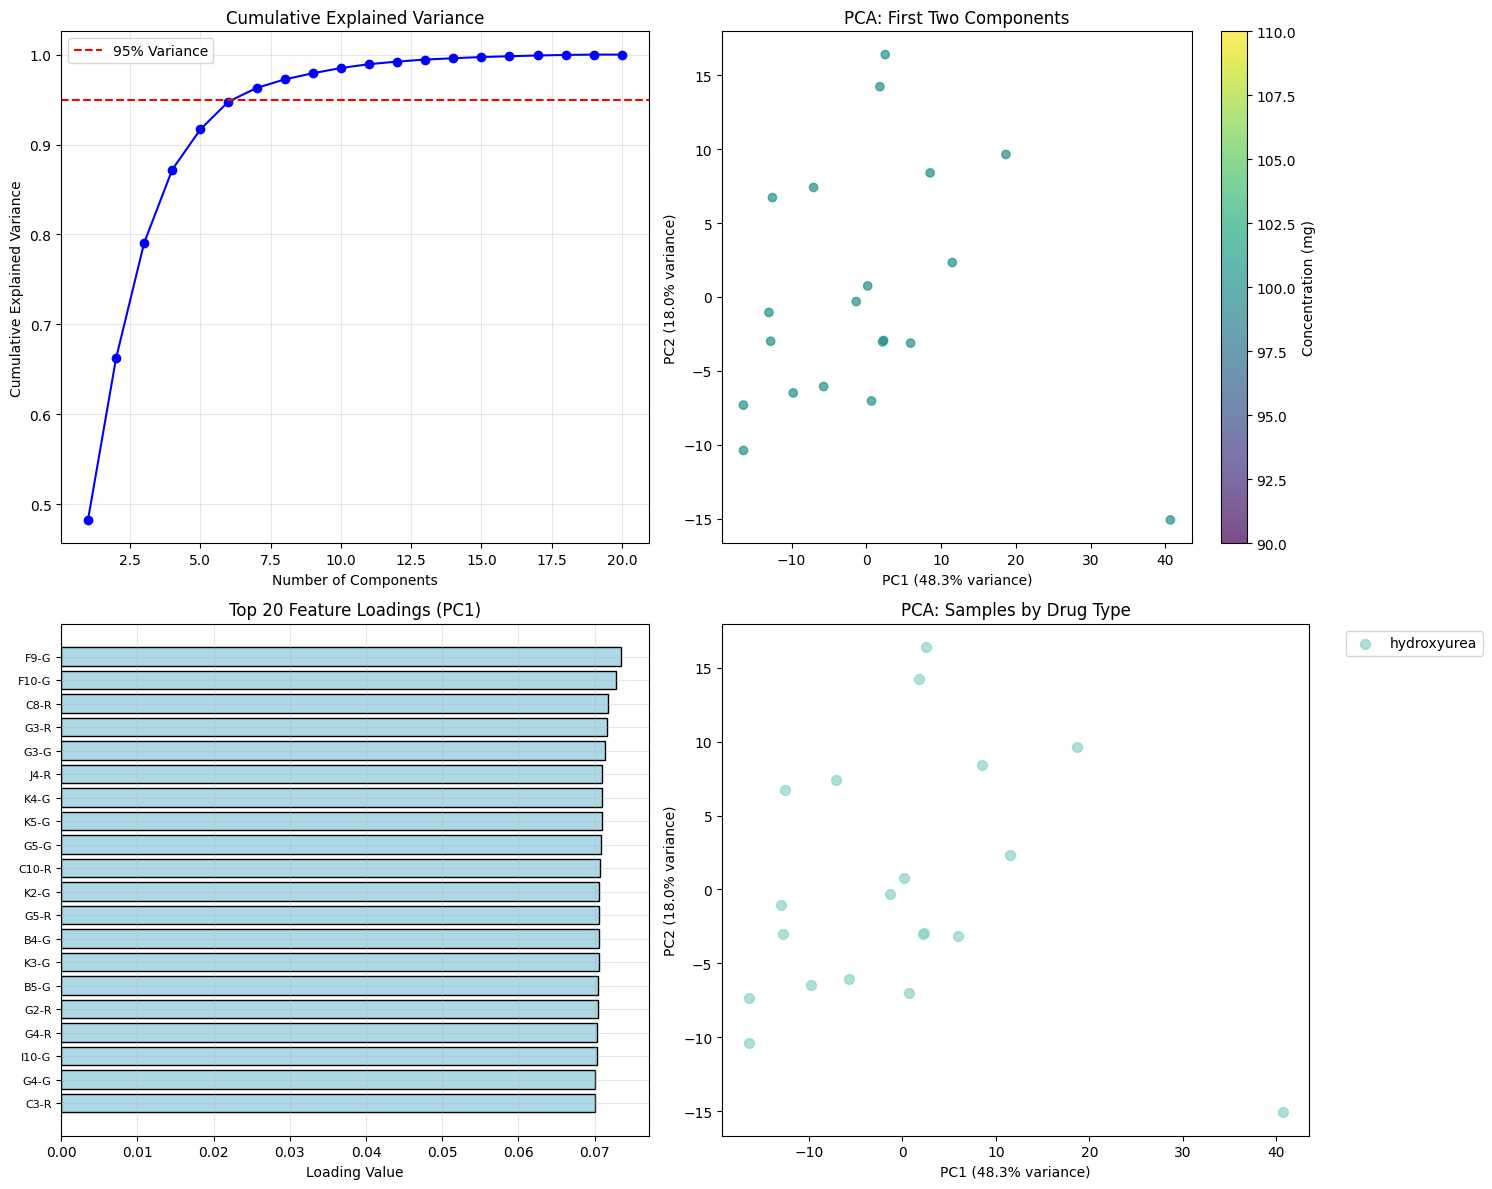


📊 PCA Analysis Summary:
   • Total samples analyzed: 20
   • Original features: 360
   • First 5 PCs explain: 91.7% of variance
   • First 10 PCs explain: 98.5% of variance
   • Components for 95% variance: 7


In [9]:
def perform_pca_analysis(metadata_df, num_samples=50):
    """Perform PCA analysis on RGB features from multiple images."""
    
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    
    print(f"🔄 Extracting features from {num_samples} images...")
    
    # Extract features from multiple images
    feature_matrix = []
    sample_info = []
    
    for i in range(min(num_samples, len(metadata_df))):
        row = metadata_df.iloc[i]
        features, _ = extract_rgb_features(row['url'])
        
        if features and len(features) > 100:  # Ensure we have enough features
            # Convert to ordered feature vector
            feature_vector = []
            lanes = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']
            for lane in lanes:
                for region in range(1, 11):
                    for color in ['R', 'G', 'B']:
                        key = f"{lane}{region}-{color}"
                        feature_vector.append(features.get(key, 0))
            
            feature_matrix.append(feature_vector)
            sample_info.append({
                'id': row['id'],
                'sample': row['sample_name'],
                'quantity': row['quantity']
            })
        
        if i % 10 == 0:
            print(f"   Processed {i+1}/{num_samples} images...")
    
    if len(feature_matrix) < 5:
        print("❌ Not enough valid samples for PCA analysis")
        return None
    
    # Convert to numpy array
    X = np.array(feature_matrix)
    print(f"✅ Feature matrix shape: {X.shape}")
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Perform PCA
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)
    
    # Visualize results
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Explained variance ratio
    cumsum_var = np.cumsum(pca.explained_variance_ratio_)
    axes[0, 0].plot(range(1, min(21, len(cumsum_var)+1)), cumsum_var[:20], 'bo-')
    axes[0, 0].axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
    axes[0, 0].set_title('Cumulative Explained Variance')
    axes[0, 0].set_xlabel('Number of Components')
    axes[0, 0].set_ylabel('Cumulative Explained Variance')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. First two principal components
    scatter = axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], 
                                c=[info['quantity'] for info in sample_info], 
                                cmap='viridis', alpha=0.7)
    axes[0, 1].set_title('PCA: First Two Components')
    axes[0, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    axes[0, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    plt.colorbar(scatter, ax=axes[0, 1], label='Concentration (mg)')
    
    # 3. Component loadings (first PC)
    feature_names = []
    lanes = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']
    for lane in lanes:
        for region in range(1, 11):
            for color in ['R', 'G', 'B']:
                feature_names.append(f"{lane}{region}-{color}")
    
    # Show top contributing features
    pc1_loadings = pca.components_[0]
    top_indices = np.argsort(np.abs(pc1_loadings))[-20:]
    
    axes[1, 0].barh(range(len(top_indices)), pc1_loadings[top_indices], 
                    color='lightblue', edgecolor='black')
    axes[1, 0].set_title('Top 20 Feature Loadings (PC1)')
    axes[1, 0].set_xlabel('Loading Value')
    axes[1, 0].set_yticks(range(len(top_indices)))
    axes[1, 0].set_yticklabels([feature_names[i] for i in top_indices], fontsize=8)
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Sample grouping by drug type
    unique_samples = list(set([info['sample'] for info in sample_info]))
    colors = plt.cm.Set3(np.linspace(0, 1, len(unique_samples)))
    
    for i, sample in enumerate(unique_samples):
        indices = [j for j, info in enumerate(sample_info) if info['sample'] == sample]
        if indices:
            axes[1, 1].scatter(X_pca[indices, 0], X_pca[indices, 1], 
                             c=[colors[i]], label=sample, alpha=0.7, s=50)
    
    axes[1, 1].set_title('PCA: Samples by Drug Type')
    axes[1, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    axes[1, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    # Print PCA summary
    print("\n📊 PCA Analysis Summary:")
    print(f"   • Total samples analyzed: {len(feature_matrix)}")
    print(f"   • Original features: {X.shape[1]}")
    print(f"   • First 5 PCs explain: {cumsum_var[4]:.1%} of variance")
    print(f"   • First 10 PCs explain: {cumsum_var[9]:.1%} of variance")
    print(f"   • Components for 95% variance: {np.argmax(cumsum_var >= 0.95) + 1}")
    
    return {
        'pca': pca,
        'X_scaled': X_scaled,
        'X_pca': X_pca,
        'sample_info': sample_info,
        'scaler': scaler
    }

# Perform PCA analysis
print("🧮 Performing PCA Analysis on RGB Features...")
pca_results = perform_pca_analysis(metadata, num_samples=20)  # Start with smaller sample

## 📊 Feature Correlation Analysis

In [24]:
def analyze_feature_correlations(metadata_df, target_column='sample_id', num_samples=30):
    """Analyze correlations between RGB features and target variable."""
    
    print(f"🔄 Analyzing correlations for {num_samples} samples...")
    
    # Extract features and targets
    feature_data = []
    targets = []
    
    for i in range(min(num_samples, len(metadata_df))):
        row = metadata_df.iloc[i]
        features, _ = extract_rgb_features(row['url'])
        
        if features and len(features) > 100:
            # Convert to ordered feature vector
            feature_vector = []
            lanes = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']
            for lane in lanes:
                for region in range(1, 11):
                    for color in ['R', 'G', 'B']:
                        key = f"{lane}{region}-{color}"
                        feature_vector.append(features.get(key, 0))
            
            feature_data.append(feature_vector)
            targets.append(row[target_column])
    
    if len(feature_data) < 5:
        print("❌ Not enough samples for correlation analysis")
        return None
    
    # Calculate correlations
    X = np.array(feature_data)
    y = np.array(targets)
    
    correlations = []
    feature_names = []
    lanes = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']
    
    for i, lane in enumerate(lanes):
        for region in range(1, 11):
            for color in ['R', 'G', 'B']:
                feature_name = f"{lane}{region}-{color}"
                feature_idx = i * 30 + (region-1) * 3 + ['R', 'G', 'B'].index(color)
                
                if feature_idx < X.shape[1]:
                    corr = np.corrcoef(X[:, feature_idx], y)[0, 1]
                    if not np.isnan(corr):
                        correlations.append(corr)
                        feature_names.append(feature_name)
    
    # Visualize correlations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Correlation distribution
    axes[0, 0].hist(correlations, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Distribution of Feature Correlations')
    axes[0, 0].set_xlabel(f'Correlation with {target_column}')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].axvline(x=0, color='red', linestyle='--', alpha=0.7)
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Top positive correlations
    top_pos_idx = np.argsort(correlations)[-15:]
    top_pos_corr = [correlations[i] for i in top_pos_idx]
    top_pos_names = [feature_names[i] for i in top_pos_idx]
    
    axes[0, 1].barh(range(len(top_pos_corr)), top_pos_corr, 
                    color='green', alpha=0.7, edgecolor='black')
    axes[0, 1].set_title('Top Positive Correlations')
    axes[0, 1].set_xlabel(f'Correlation with {target_column}')
    axes[0, 1].set_yticks(range(len(top_pos_corr)))
    axes[0, 1].set_yticklabels(top_pos_names, fontsize=8)
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Top negative correlations
    top_neg_idx = np.argsort(correlations)[:15]
    top_neg_corr = [correlations[i] for i in top_neg_idx]
    top_neg_names = [feature_names[i] for i in top_neg_idx]
    
    axes[1, 0].barh(range(len(top_neg_corr)), top_neg_corr, 
                    color='red', alpha=0.7, edgecolor='black')
    axes[1, 0].set_title('Top Negative Correlations')
    axes[1, 0].set_xlabel(f'Correlation with {target_column}')
    axes[1, 0].set_yticks(range(len(top_neg_corr)))
    axes[1, 0].set_yticklabels(top_neg_names, fontsize=8)
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Correlation by lane
    lane_correlations = {}
    for lane in lanes:
        lane_corrs = [corr for i, corr in enumerate(correlations) 
                     if feature_names[i].startswith(lane)]
        if lane_corrs:
            lane_correlations[lane] = np.mean(np.abs(lane_corrs))
        else:
            lane_correlations[lane] = 0
    
    axes[1, 1].bar(lane_correlations.keys(), lane_correlations.values(), 
                   color='skyblue', edgecolor='black')
    axes[1, 1].set_title('Average Absolute Correlation by Lane')
    axes[1, 1].set_xlabel('Lane')
    axes[1, 1].set_ylabel('Mean |Correlation|')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print correlation summary
    print("\n📊 Correlation Analysis Summary:")
    print(f"   • Features analyzed: {len(correlations)}")
    print(f"   • Max positive correlation: {max(correlations):.3f}")
    print(f"   • Max negative correlation: {min(correlations):.3f}")
    print(f"   • Mean absolute correlation: {np.mean(np.abs(correlations)):.3f}")
    
    return {
        'correlations': correlations,
        'feature_names': feature_names,
        'lane_correlations': lane_correlations
    }

# Analyze correlations
print("📊 Analyzing Feature Correlations...")
corr_results = analyze_feature_correlations(metadata, target_column='sample_name', num_samples=15)

📊 Analyzing Feature Correlations...
🔄 Analyzing correlations for 15 samples...
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
Image loaded: (1220, 730, 3)
✅ Extracted 360 features


UFuncTypeError: ufunc 'add' did not contain a loop with signature matching types (dtype('<U32'), dtype('<U32')) -> None

In [18]:
def analyze_feature_correlations(metadata_df, target_column='sample_id', num_samples=30):
    """Analyze correlations between RGB features and target variable."""

    # First, check target diversity
    target_values = metadata_df[target_column].values
    target_variance = np.var(target_values)
    unique_targets = len(np.unique(target_values))

    print(f"🎯 Target Variable Analysis ({target_column}):")
    print(f"   • Unique values: {unique_targets}")
    print(f"   • Variance: {target_variance:.3f}")
    print(f"   • Range: {target_values.min():.1f} - {target_values.max():.1f}")

    if target_variance < 0.001:
        print(f"❌ Target '{target_column}' has insufficient variance for correlation analysis")
        print("   Try a different target column or ensure diverse samples")
        return None

    print(f"✅ Target has sufficient variance for correlation analysis")
    print(f"🔄 Analyzing correlations for {num_samples} samples...")

🔍 Debugging correlation analysis with 10 samples...
Processing sample 1: Card 47986
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
  ✅ Added sample (missing 0 features)
Processing sample 2: Card 47987
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
  ✅ Added sample (missing 0 features)
Processing sample 3: Card 47988
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
  ✅ Added sample (missing 0 features)
Processing sample 4: Card 47989
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
  ✅ Added sample (missing 0 features)
Processing sample 5: Card 47990
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
  ✅ Added sample (missing 0 features)
Processing sample 6: Card 47991
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
  ✅ Added sample (missing 0 features)
Processing sample 7: Card 47992
Image loaded: (1220, 730, 3)
✅ Extracted 360 features
  ✅ Added sample (missing 0 features)
Processing sample 8: Card 47993
Image loaded: (1220, 730, 3)
✅ Extracted 360 fea

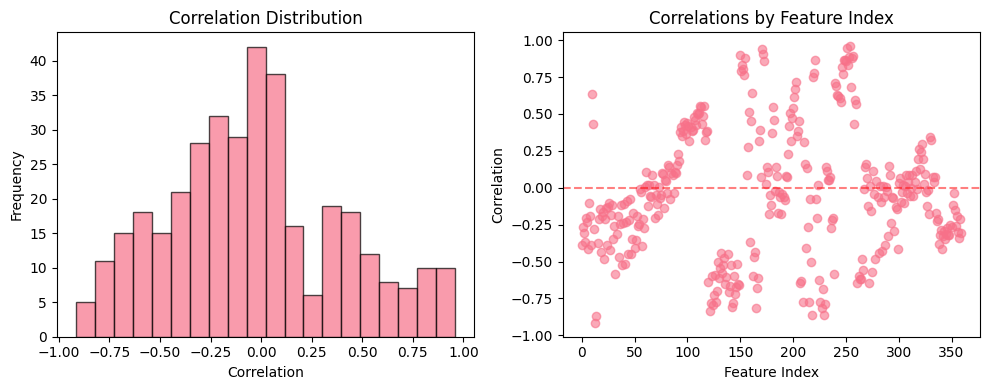

[-0.38585536132522946,
 -0.26691604809501585,
 -0.3084958878068453,
 -0.36539204762093486,
 -0.20520658014776755,
 -0.22956639546546728,
 -0.4174464720704105,
 -0.10016708449412666,
 -0.19356484095744073,
 -0.39120505990341786,
 0.6354247894833294,
 0.43168408760289223,
 -0.2805440487178745,
 -0.9157529737596233,
 -0.8660201658595653,
 -0.3733333333333333,
 -0.21100517991219223,
 -0.1427639396876344,
 -0.43590203258367816,
 -0.19191379633002909,
 -0.16308865737445194,
 -0.4847209167050645,
 -0.2085852770715443,
 -0.13529818025171333,
 -0.3877373806400902,
 -0.129566835134765,
 -0.10047221272611696,
 -0.41971385269544165,
 -0.18310719317631435,
 -0.1181895751659023,
 -0.3446785649577052,
 -0.26077715112750405,
 -0.5865959281929414,
 -0.31576100891221914,
 -0.1921179926925629,
 -0.4688784704280575,
 -0.24505049551302377,
 -0.11900165942359855,
 -0.5246633752066131,
 -0.23780079317205896,
 -0.11174730713709385,
 -0.5189372667903687,
 -0.2338483669020087,
 -0.08818471185987171,
 -0.4461880

In [19]:
debug_results = debug_correlation_analysis(metadata, num_samples=10)
debug_results

In [26]:
metadata

,id,sample_id,sample_name,quantity,camera_type_1,url,hashlib_md5,image_name
0,47986,80903,hydroxyurea,100,iPad,https://pad.crc.nd.edu//var/www/html/images/pa...,77ebff74a025589d0c64086b72c2a7c0,47986__80903__hydroxyurea__100.png
1,47987,81560,hydroxyurea,100,HMD Global Nokia 2.3,https://pad.crc.nd.edu//var/www/html/images/pa...,aa5b30f2bdd606ff71809a3e05f5893c,47987__81560__hydroxyurea__100.png
2,47988,81560,hydroxyurea,100,iPad,https://pad.crc.nd.edu//var/www/html/images/pa...,a2b33fab29403d5821476cf5f685e9c4,47988__81560__hydroxyurea__100.png
3,47989,80903,hydroxyurea,100,HMD Global Nokia 2.3,https://pad.crc.nd.edu//var/www/html/images/pa...,741512bbfc80b64400eb785f1f837dec,47989__80903__hydroxyurea__100.png
4,47990,81560,hydroxyurea,100,HMD Global Nokia 2.3,https://pad.crc.nd.edu//var/www/html/images/pa...,c78c9f865c2fa435b9eed5256fa7aec0,47990__81560__hydroxyurea__100.png
...,...,...,...,...,...,...,...,...
3604,53250,82201,mtx-injectable,33,unknown,https://pad.crc.nd.edu//var/www/html/images/pa...,2ef0cb7148e678fdb78a5d289a229272,53250__82201__mtx-injectable__33.png
3605,53251,82201,mtx-injectable,33,unknown,https://pad.crc.nd.edu//var/www/html/images/pa...,29337917273b620dc242b5dbba443032,53251__82201__mtx-injectable__33.png
3606,53252,82201,mtx-injectable,33,unknown,https://pad.crc.nd.edu//var/www/html/images/pa...,a3f76d4ab4b9d07cadc89c77eb86e25b,53252__82201__mtx-injectable__33.png
3607,53253,82201,mtx-injectable,33,unknown,https://pad.crc.nd.edu//var/www/html/images/pa...,6f6ffb7b88f94e09a31ecb844fe695dd,53253__82201__mtx-injectable__33.png


In [27]:
metadata.columns

Index(['id', 'sample_id', 'sample_name', 'quantity', 'camera_type_1', 'url',
       'hashlib_md5', 'image_name'],
      dtype='object')

In [31]:
metadata['id']

0       47986
1       47987
2       47988
3       47989
4       47990
        ...  
3604    53250
3605    53251
3606    53252
3607    53253
3608    53254
Name: id, Length: 3609, dtype: int64

In [32]:
col

'id'

In [33]:
# Let participants choose the target
print("Available target variables:")
for col in metadata.columns:
    if col in ['id', 'sample_id', 'sample_name', 'quantity', 'camera_type_1']:
        unique_vals = len(metadata[col].unique())
        variance = np.var(metadata[col].values)
        print(f"  • {col}: {unique_vals} unique values, variance={variance:.1f}")

Available target variables:
  • id: 3609 unique values, variance=2518837.9
  • sample_id: 624 unique values, variance=5295591.8


TypeError: unsupported operand type(s) for /: 'str' and 'int'

---
# 🔗 Section 5: Hands-on Integration

Now let's integrate everything and compare different preprocessing approaches.

## 🚀 Using PreprocessingPipeline

In [16]:
# Check if PreprocessingPipeline is available
try:
    from pad_analytics import PreprocessingPipeline
    pipeline_available = True
    print("✅ PreprocessingPipeline is available!")
except ImportError as e:
    pipeline_available = False
    print(f"❌ PreprocessingPipeline not available: {e}")
    print("   We'll use direct methods instead")

if pipeline_available:
    def demonstrate_unified_pipeline():
        """Demonstrate the unified preprocessing pipeline."""
        
        # Create pipelines for different models
        nn_pipeline = PreprocessingPipeline(model_id=16)  # Neural Network
        pls_pipeline = PreprocessingPipeline(model_id=18)  # PLS
        
        print(f"NN Pipeline: {nn_pipeline}")
        print(f"PLS Pipeline: {pls_pipeline}")
        
        # Get sample data
        card_data = metadata.iloc[0].to_dict()
        
        # Process with both pipelines
        print("\n🔄 Processing same image with both pipelines...")
        
        try:
            nn_result = nn_pipeline.preprocess_single_card(card_data)
            print(f"✅ NN preprocessing: {list(nn_result.keys())}")
        except Exception as e:
            print(f"❌ NN preprocessing failed: {e}")
            nn_result = None
        
        try:
            pls_result = pls_pipeline.preprocess_single_card(card_data)
            print(f"✅ PLS preprocessing: {list(pls_result.keys())}")
        except Exception as e:
            print(f"❌ PLS preprocessing failed: {e}")
            pls_result = None
        
        # Compare results
        if nn_result and pls_result:
            print("\n📊 Comparison:")
            print(f"   NN preprocessed shape: {nn_result.get('processed_shape', 'N/A')}")
            print(f"   PLS features count: {nn_result.get('num_features', 'N/A')}")
            print(f"   NN model type: {nn_result.get('preprocessor_type', 'N/A')}")
            print(f"   PLS model type: {pls_result.get('preprocessor_type', 'N/A')}")
        
        return nn_result, pls_result
    
    # Run demonstration
    nn_demo_result, pls_demo_result = demonstrate_unified_pipeline()
else:
    print("\n💡 PreprocessingPipeline demo skipped - fix the bug first!")
    print("   Once fixed, restart this notebook and run this cell again.")

✅ PreprocessingPipeline is available!
NN Pipeline: PreprocessingPipeline(model_id=16, type=neuralnetwork, preprocessor=NeuralNetworkPreprocessor)
PLS Pipeline: PreprocessingPipeline(model_id=18, type=pls, preprocessor=PLSPreprocessor)

🔄 Processing same image with both pipelines...
✅ NN preprocessing: ['card_id', 'preprocessed_image', 'original_shape', 'processed_shape', 'model_id', 'preprocessor_type', 'sample_name', 'sample_id']
✅ PLS preprocessing: ['card_id', 'features', 'feature_names', 'num_features', 'model_id', 'preprocessor_type', 'sample_name', 'sample_id']

📊 Comparison:
   NN preprocessed shape: (1, 454, 454, 3)
   PLS features count: N/A
   NN model type: neural_network
   PLS model type: pls


## 📋 Preprocessing Comparison Summary

📋 Preprocessing Approaches Comparison:


,Aspect,Neural Network,PLS/Linear
0,Input Format,Raw RGB image,Raw RGB image
1,Image Processing,Crop + Resize (454×454),Lane segmentation
2,Feature Type,Pixel values,Region RGB averages
3,Feature Count,"618,348 (454×454×3)",360 (12×10×3)
4,Output Format,Normalized array,Feature vector
5,Use Case,End-to-end learning,Interpretable analysis
6,Preprocessing Time,Fast,Moderate
7,Memory Usage,High,Low


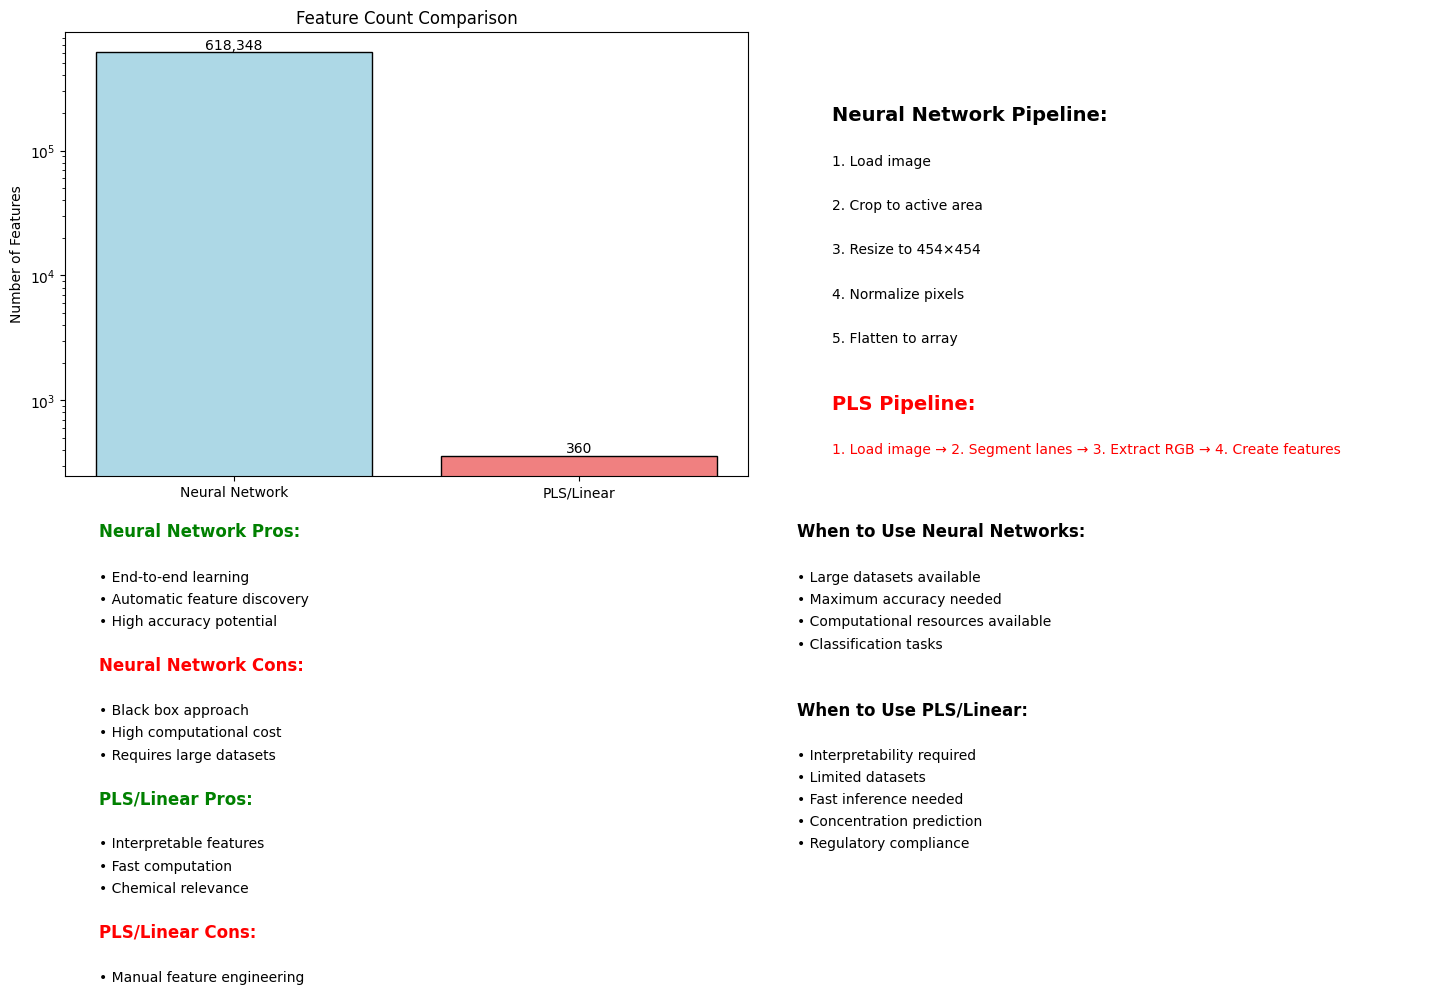

In [17]:
def create_preprocessing_summary():
    """Create a comprehensive summary of preprocessing approaches."""
    
    # Create comparison table
    comparison_data = {
        'Aspect': [
            'Input Format',
            'Image Processing',
            'Feature Type',
            'Feature Count',
            'Output Format',
            'Use Case',
            'Preprocessing Time',
            'Memory Usage'
        ],
        'Neural Network': [
            'Raw RGB image',
            'Crop + Resize (454×454)',
            'Pixel values',
            '618,348 (454×454×3)',
            'Normalized array',
            'End-to-end learning',
            'Fast',
            'High'
        ],
        'PLS/Linear': [
            'Raw RGB image',
            'Lane segmentation',
            'Region RGB averages',
            '360 (12×10×3)',
            'Feature vector',
            'Interpretable analysis',
            'Moderate',
            'Low'
        ]
    }
    
    comparison_df = pd.DataFrame(comparison_data)
    
    print("📋 Preprocessing Approaches Comparison:")
    print("=" * 80)
    display(comparison_df)
    
    # Create visual comparison
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Feature count comparison
    methods = ['Neural Network', 'PLS/Linear']
    feature_counts = [618348, 360]
    
    axes[0, 0].bar(methods, feature_counts, color=['lightblue', 'lightcoral'], edgecolor='black')
    axes[0, 0].set_title('Feature Count Comparison')
    axes[0, 0].set_ylabel('Number of Features')
    axes[0, 0].set_yscale('log')
    
    # Add value labels
    for i, v in enumerate(feature_counts):
        axes[0, 0].text(i, v, f'{v:,}', ha='center', va='bottom')
    
    # 2. Processing workflow
    axes[0, 1].text(0.1, 0.8, 'Neural Network Pipeline:', fontsize=14, fontweight='bold', 
                    transform=axes[0, 1].transAxes)
    axes[0, 1].text(0.1, 0.7, '1. Load image', transform=axes[0, 1].transAxes)
    axes[0, 1].text(0.1, 0.6, '2. Crop to active area', transform=axes[0, 1].transAxes)
    axes[0, 1].text(0.1, 0.5, '3. Resize to 454×454', transform=axes[0, 1].transAxes)
    axes[0, 1].text(0.1, 0.4, '4. Normalize pixels', transform=axes[0, 1].transAxes)
    axes[0, 1].text(0.1, 0.3, '5. Flatten to array', transform=axes[0, 1].transAxes)
    
    axes[0, 1].text(0.1, 0.15, 'PLS Pipeline:', fontsize=14, fontweight='bold', 
                    transform=axes[0, 1].transAxes, color='red')
    axes[0, 1].text(0.1, 0.05, '1. Load image → 2. Segment lanes → 3. Extract RGB → 4. Create features', 
                    transform=axes[0, 1].transAxes, color='red')
    axes[0, 1].set_xlim(0, 1)
    axes[0, 1].set_ylim(0, 1)
    axes[0, 1].axis('off')
    
    # 3. Advantages and disadvantages
    axes[1, 0].text(0.05, 0.95, 'Neural Network Pros:', fontsize=12, fontweight='bold', 
                    transform=axes[1, 0].transAxes, color='green')
    axes[1, 0].text(0.05, 0.85, '• End-to-end learning', transform=axes[1, 0].transAxes)
    axes[1, 0].text(0.05, 0.80, '• Automatic feature discovery', transform=axes[1, 0].transAxes)
    axes[1, 0].text(0.05, 0.75, '• High accuracy potential', transform=axes[1, 0].transAxes)
    
    axes[1, 0].text(0.05, 0.65, 'Neural Network Cons:', fontsize=12, fontweight='bold', 
                    transform=axes[1, 0].transAxes, color='red')
    axes[1, 0].text(0.05, 0.55, '• Black box approach', transform=axes[1, 0].transAxes)
    axes[1, 0].text(0.05, 0.50, '• High computational cost', transform=axes[1, 0].transAxes)
    axes[1, 0].text(0.05, 0.45, '• Requires large datasets', transform=axes[1, 0].transAxes)
    
    axes[1, 0].text(0.05, 0.35, 'PLS/Linear Pros:', fontsize=12, fontweight='bold', 
                    transform=axes[1, 0].transAxes, color='green')
    axes[1, 0].text(0.05, 0.25, '• Interpretable features', transform=axes[1, 0].transAxes)
    axes[1, 0].text(0.05, 0.20, '• Fast computation', transform=axes[1, 0].transAxes)
    axes[1, 0].text(0.05, 0.15, '• Chemical relevance', transform=axes[1, 0].transAxes)
    
    axes[1, 0].text(0.05, 0.05, 'PLS/Linear Cons:', fontsize=12, fontweight='bold', 
                    transform=axes[1, 0].transAxes, color='red')
    axes[1, 0].text(0.05, -0.05, '• Manual feature engineering', transform=axes[1, 0].transAxes)
    axes[1, 0].axis('off')
    
    # 4. When to use which
    axes[1, 1].text(0.05, 0.95, 'When to Use Neural Networks:', fontsize=12, fontweight='bold', 
                    transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.05, 0.85, '• Large datasets available', transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.05, 0.80, '• Maximum accuracy needed', transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.05, 0.75, '• Computational resources available', transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.05, 0.70, '• Classification tasks', transform=axes[1, 1].transAxes)
    
    axes[1, 1].text(0.05, 0.55, 'When to Use PLS/Linear:', fontsize=12, fontweight='bold', 
                    transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.05, 0.45, '• Interpretability required', transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.05, 0.40, '• Limited datasets', transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.05, 0.35, '• Fast inference needed', transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.05, 0.30, '• Concentration prediction', transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.05, 0.25, '• Regulatory compliance', transform=axes[1, 1].transAxes)
    
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return comparison_df

# Create comprehensive summary
comparison_summary = create_preprocessing_summary()

---
# 🎯 Workshop Conclusion

## 🎉 What We've Accomplished

1. **✅ PAD Image Processing Fundamentals**
   - Understood PAD structure and challenges
   - Explored image loading and visualization

2. **✅ Neural Network Preprocessing**
   - Image cropping and resizing techniques
   - Pixel normalization strategies
   - Array format conversion

3. **✅ Lane Segmentation & RGB Extraction**
   - PAD lane structure (A-L lanes, 10 regions)
   - RGB feature extraction using regionRoutine
   - Feature organization and analysis

4. **✅ Linear Analysis Techniques**
   - PCA for dimensionality reduction
   - Feature correlation analysis
   - Preprocessing pipeline comparison

5. **✅ Integration and Comparison**
   - Unified preprocessing interface
   - Performance and use case analysis
   - Best practices recommendations

## 🚀 Next Steps

### For Day 3 - Neural Network Training:
- Use preprocessed data from today's workshop
- Implement TensorFlow/Keras training pipelines
- Model evaluation and optimization

### Further Exploration:
- Try different normalization techniques
- Experiment with feature selection methods
- Compare preprocessing performance on larger datasets
- Implement custom preprocessing pipelines

## 📚 Key Takeaways

1. **Choose preprocessing based on your model type and goals**
2. **Neural networks need pixel-level data, linear models need engineered features**
3. **PAD lane structure provides chemically meaningful features**
4. **Preprocessing pipeline unifies different approaches**
5. **Always validate preprocessing with real data**

---

## 🛠️ Workshop Code Repository

All code from this workshop is available in the PAD Analytics repository:
- **Preprocessing Pipeline**: `src/pad_analytics/preprocessing_pipeline.py`
- **Neural Network Preprocessor**: `src/pad_analytics/preprocessors/nn_preprocessor.py`
- **PLS Preprocessor**: `src/pad_analytics/preprocessors/pls_preprocessor.py`
- **Region Routine**: `src/pad_analytics/regionRoutine.py`

**Questions? Issues? Suggestions?**
Feel free to ask during the Q&A session!